# Quick Sanity Check — Simple Model & Backtest

**Goal:** Verify the pipeline works with honest rolling β and 60-day features.

**Method:**
- Load feature matrix with selected features
- Train XGBoost with PurgedKFold cross-validation
- Simple backtest on hold-out test set
- Report Sharpe ratio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

# Load feature matrix
df = pd.read_csv(
    r"C:\Users\roosd\Downloads\econometrie jaar 3\TIC\Spring2026-TIC\data\feature_matrix.csv",
    index_col='date',
    parse_dates=True
)

print(f"Loaded: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")

Loaded: (4667, 138)
Date range: 2007-07-16 to 2026-02-02


In [2]:
# Load selected features
selected = pd.read_csv(
    r"C:\Users\roosd\Downloads\econometrie jaar 3\TIC\Spring2026-TIC\data\selected_features.csv"
)['selected_features'].tolist()

print(f"Selected features ({len(selected)}):")
for f in selected:
    print(f"  {f}")

Selected features (8):
  ecm_spread
  cloud_cover_mean_loc3.0
  cloud_cover_max_loc2.0
  surface_pressure_max_loc2.0
  cloud_cover_max_loc1.0
  wind_speed_10m_max_loc1.0
  dew_point_2m_min_loc3.0
  soil_moisture_28_to_100cm_mean_loc3.0


In [3]:
# Build X and y
X = df[selected].copy()
y_raw = df['bin'].copy()
ret = df['ret'].copy()

# Drop NaN labels
valid = y_raw.notna()
X = X[valid]
y_raw = y_raw[valid]
ret = ret[valid]

# Remap labels
label_map = {-1.0: 0, 0.0: 1, 1.0: 2}
y = y_raw.map(label_map).astype(int)

print(f"\nX shape: {X.shape}")
print(f"y distribution:")
print(y.value_counts().sort_index())


X shape: (4667, 8)
y distribution:
bin
0    2413
1      10
2    2244
Name: count, dtype: int64


In [4]:
# PurgedKFold
class PurgedKFold(KFold):
    def __init__(self, n_splits=5, t1=None, pct_embargo=0.01):
        super().__init__(n_splits, shuffle=False, random_state=None)
        self.t1 = t1
        self.pct_embargo = pct_embargo

    def split(self, X, y=None, groups=None):
        if not isinstance(X.index, pd.DatetimeIndex):
            raise ValueError("X must have DatetimeIndex")
        
        mbrg = int(X.shape[0] * self.pct_embargo)
        
        for train_idx, test_idx in super().split(X, y, groups):
            test_start = X.index[test_idx[0]]
            test_end = X.index[test_idx[-1]]
            embargo_idx = min(test_idx[-1] + mbrg, X.shape[0] - 1)
            embargo_end = X.index[embargo_idx]
            
            t1_train = self.t1.iloc[train_idx]
            purged = []
            
            for i, t1_val in zip(train_idx, t1_train.values):
                t0_val = X.index[i]
                if t1_val >= test_start and t0_val <= test_end:
                    continue
                if test_end <= t0_val < embargo_end:
                    continue
                purged.append(i)
            
            yield np.array(purged), test_idx

# t1 proxy (60-day barrier)
t1_proxy = pd.Series(
    X.index[np.clip(X.index.searchsorted(X.index + pd.Timedelta(days=60)), 0, len(X.index) - 1)],
    index=X.index
)

cv = PurgedKFold(n_splits=5, t1=t1_proxy, pct_embargo=0.01)
print("PurgedKFold ready")

PurgedKFold ready


In [5]:
# Cross-validation
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

cv_accs = []

print("Running 5-fold PurgedKFold CV...\n")

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    cv_accs.append(acc)
    
    print(f"Fold {fold+1}: accuracy = {acc:.3f}")

print(f"\nMean CV accuracy: {np.mean(cv_accs):.3f} ± {np.std(cv_accs):.3f}")

Running 5-fold PurgedKFold CV...

Fold 1: accuracy = 0.587
Fold 2: accuracy = 0.565
Fold 3: accuracy = 0.532
Fold 4: accuracy = 0.597
Fold 5: accuracy = 0.577

Mean CV accuracy: 0.571 ± 0.023


In [6]:
# Train/test split (time-based)
split_idx = int(0.75 * len(X))

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]
ret_test = ret.iloc[split_idx:]

print(f"Train: {len(X_train)} | {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Test:  {len(X_test)} | {X_test.index.min().date()} to {X_test.index.max().date()}")

Train: 3500 | 2007-07-16 to 2021-06-10
Test:  1167 | 2021-06-11 to 2026-02-02


In [7]:
# Train final model
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

y_test_pred = final_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Test accuracy: {test_acc:.3f}")

Test accuracy: 0.567


In [8]:
# Simple backtest (constant position sizing)
proba = final_model.predict_proba(X_test)

results = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_test_pred,
    'max_prob': proba.max(axis=1),
    'predicted_class': proba.argmax(axis=1),
    'ret': ret_test.values
}, index=X_test.index)

# Trade when confident and not predicting timeout
THRESHOLD = 0.50
results['trade'] = (
    (results['max_prob'] >= THRESHOLD) &
    (results['predicted_class'] != 1)
).astype(int)

# Position: +1 if predict PT, -1 if predict SL
results['position'] = np.where(
    results['trade'] == 1,
    np.where(results['predicted_class'] == 2, 1, -1),
    0
)

results['pnl'] = results['position'] * results['ret']

# Metrics
mean_pnl = results['pnl'].mean()
std_pnl = results['pnl'].std()
sharpe = (mean_pnl / std_pnl) * np.sqrt(252) if std_pnl > 0 else 0

trades = results[results['trade'] == 1]
win_rate = (trades['pnl'] > 0).mean() if len(trades) > 0 else 0

print("\n" + "="*80)
print("BACKTEST RESULTS (Honest — Rolling β, 60-day features)")
print("="*80)
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Win Rate: {win_rate*100:.1f}%")
print(f"Trades: {results['trade'].sum()}")
print(f"Total PnL: {results['pnl'].sum():.4f}")
print("="*80)


BACKTEST RESULTS (Honest — Rolling β, 60-day features)
Sharpe Ratio: 1.99
Win Rate: 56.9%
Trades: 1166
Total PnL: 4.3927


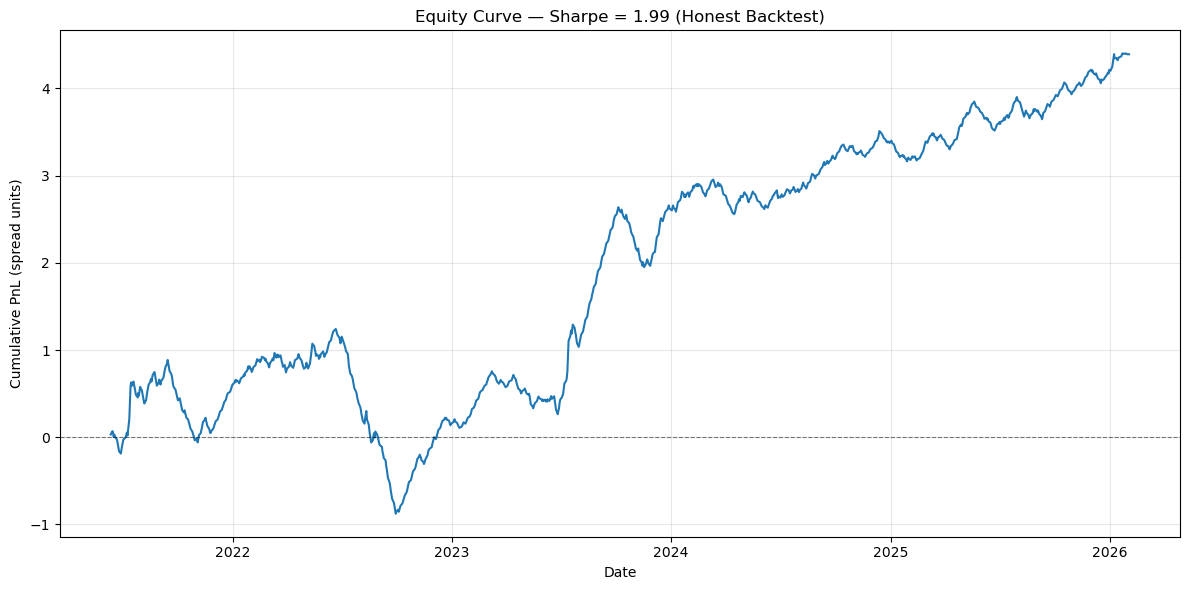

In [9]:
# Equity curve
results['cumulative_pnl'] = results['pnl'].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(results.index, results['cumulative_pnl'], linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Cumulative PnL (spread units)')
plt.title(f'Equity Curve — Sharpe = {sharpe:.2f} (Honest Backtest)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()